<a href="https://colab.research.google.com/github/Yuliia-Safonova/coffee_sales_forecast/blob/main/notebooks/coffee_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ☕ Прогнозування продажів кав'ярні (Forecast)

## Завдання з машинного навчання для початківців

У цьому проєкті ви навчите просту модель, яка **прогнозує майбутні продажі** на основі минулих даних. Ми використаємо `scikit-learn` — найпопулярнішу бібліотеку машинного навчання в Python.

**Не хвилюйтесь, якщо мало досвіду з Python** — більшість коду вже написана. Ваше завдання:
1. Запускати клітинки по черзі (Shift + Enter)
2. Заповнити кілька пропусків, позначених `# ⬅️ ВАШ КОД`
3. **Головне — інтерпретувати результати** (відповіді пишіть у клітинках з питаннями)

---

### Легенда
Ви — аналітик мережі кав'ярень **"CoffeeTime"**. У вас є дані про щомісячну виручку за 3 роки (2022–2024). Директор хоче знати: **скільки ми зароблятимемо в наступні місяці?** Побудуйте прогноз і поясніть його простими словами.

## Крок 1. Підключаємо бібліотеки

Спочатку завантажимо потрібні інструменти. Просто запустіть цю клітинку — тут нічого міняти не треба.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("Бібліотеки підключено! ✅")

Бібліотеки підключено! ✅


In [13]:
FILE_IN = 'https://raw.githubusercontent.com/Yuliia-Safonova/coffee_sales_forecast/refs/heads/main/data/coffee_sales.csv'

## Крок 2. Завантажуємо дані

Прочитаємо файл `coffee_sales.csv` і подивимось на перші рядки.

In [14]:
# df = pd.read_csv("coffee_sales.csv")
df = pd.read_csv(FILE_IN)

# Подивимось на перші 5 рядків
df.head()

,month_number,year,month,month_name,revenue
0,1,2022,1,Січень,12499
1,2,2022,2,Лютий,11712
2,3,2022,3,Березень,14006
3,4,2022,4,Квітень,15618
4,5,2022,5,Травень,14688


**Що означають стовпці:**
- `month_number` — порядковий номер місяця (1, 2, 3 ... 36). Це наш **головний вхідний параметр** (X)
- `year`, `month`, `month_name` — рік, номер і назва місяця (для зручності)
- `revenue` — виручка за місяць у гривнях. Це те, що ми **прогнозуємо** (y)

In [15]:
# Скільки в нас даних?
print(f"Кількість місяців у даних: {len(df)}")
print(f"Перший місяць: {df['revenue'].iloc[0]} грн")
print(f"Останній місяць: {df['revenue'].iloc[-1]} грн")

Кількість місяців у даних: 36
Перший місяць: 12499 грн
Останній місяць: 30642 грн


## Крок 3. Дивимось на дані очима

Перш ніж щось прогнозувати, аналітик **завжди спочатку дивиться на графік**. Побудуємо графік виручки за всі 36 місяців.

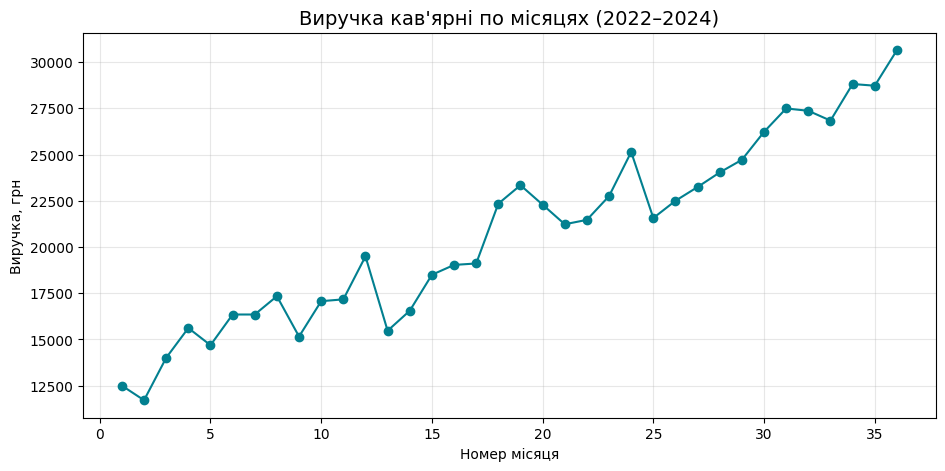

In [16]:
plt.figure(figsize=(11, 5))
plt.plot(df["month_number"], df["revenue"], marker="o", color="#028090")
plt.title("Виручка кав'ярні по місяцях (2022–2024)", fontsize=14)
plt.xlabel("Номер місяця")
plt.ylabel("Виручка, грн")
plt.grid(alpha=0.3)
plt.show()

### ❓ Питання 1 (інтерпретація)

Подивіться на графік уважно і дайте відповідь текстом:

1. Який **загальний напрямок** руху виручки? (зростає / падає / стоїть на місці)
2. Чи бачите ви якісь **регулярні коливання** (наприклад, сезонні піки влітку чи взимку)?
3. Як гадаєте, чи можна за таким графіком приблизно вгадати, що буде далі?  

💡 *UA Відповідь*

Загальний напрямок руху виручки є зростаючим. Протягом усього періоду спостерігається поступове збільшення щомісячної виручки, хоча в окремі місяці є незначні спади та підйоми.

На графіку помітні певні коливання, проте вони не є достатньо регулярними, щоб упевнено говорити про виражену сезонність. Для підтвердження сезонних закономірностей потрібен детальніший аналіз.

За таким графіком можна припустити, що виручка й надалі зростатиме. Однак це лише попереднє припущення, яке необхідно перевірити за допомогою моделі прогнозування.  

---

💡 *DE Interpretation*

Der Umsatz zeigt insgesamt einen steigenden Trend. Im gesamten Beobachtungszeitraum nimmt der monatliche Umsatz schrittweise zu, obwohl es in einzelnen Monaten kleinere Schwankungen nach oben und unten gibt.

Im Diagramm sind zwar gewisse Schwankungen erkennbar, sie sind jedoch nicht regelmäßig genug, um eindeutig auf eine saisonale Entwicklung zu schließen. Dafür wäre eine detailliertere Analyse erforderlich.

Anhand des Diagramms lässt sich vermuten, dass der Umsatz auch in Zukunft weiter steigen könnte. Dies ist jedoch zunächst nur eine Annahme, die anschließend mit einem Regressionsmodell überprüft werden sollte.


## Крок 4. Готуємо дані для моделі

Модель навчається на парах «вхід → вихід». У нас:
- **Вхід (X)** — номер місяця (`month_number`)
- **Вихід (y)** — виручка (`revenue`)

Модель шукатиме залежність: «як виручка залежить від номера місяця».

In [17]:
# X — вхідні дані (features). Подвійні дужки [[ ]] потрібні, щоб отримати таблицю, а не список
X = df[["month_number"]]

# y — те, що прогнозуємо (target)
y = df["revenue"]

print("X (перші 3):")
print(X.head(3))
print("\ny (перші 3):")
print(y.head(3))

X (перші 3):
   month_number
0             1
1             2
2             3

y (перші 3):
0    12499
1    11712
2    14006
Name: revenue, dtype: int64


## Крок 5. Навчаємо модель

Тепер найголовніше — навчання. Ми використаємо **лінійну регресію** — найпростішу модель, яка проводить пряму лінію крізь наші точки.

Модель за нас знайде два числа:
- **нахил (slope)** — на скільки гривень зростає виручка щомісяця
- **перетин (intercept)** — з якого рівня все починалось

Заповніть один пропуск нижче: викличте `.fit(X, y)`, щоб навчити модель.

In [18]:
# Створюємо модель
model = LinearRegression()

# Навчаємо модель на наших даних
model.fit(X, y)      # ⬅️ ВАШ КОД: тут ми "показуємо" моделі дані X та y

print("Модель навчено! ✅")
print(f"Нахил (slope): {model.coef_[0]:.0f} грн на місяць")
print(f"Перетин (intercept): {model.intercept_:.0f} грн")

Модель навчено! ✅
Нахил (slope): 459 грн на місяць
Перетин (intercept): 12247 грн


### ❓ Питання 2 (інтерпретація)

Модель порахувала **нахил (slope)**. Це найважливіше число прогнозу.

1. Чому дорівнює нахил? Що він означає **простими словами** для директора кав'ярні?
   (Підказка: «Щомісяця виручка в середньому зростає на ___ грн»)
2. Перетин (intercept) — це теоретична виручка в «місяць 0». Чи має він реальний бізнес-сенс тут?

💡 *UA Відповідь*

Нахил (slope) моделі становить 459 грн на місяць. Це означає, що щомісячна виручка в середньому зростає приблизно на 459 грн. Для директора кав'ярні це свідчить про стабільне зростання виручки та позитивну динаміку розвитку бізнесу.

Перетин (intercept) дорівнює 12 247 грн. Це теоретична виручка в «місяці 0». Оскільки наші дані починаються з 1-го місяця, цей показник не має практичного бізнес-сенсу. Він є математичним параметром моделі, необхідним для побудови лінії регресії.  

---

💡 *DE Interpretation*

Die Steigung (Slope) der Regressionsgeraden beträgt 459 UAH pro Monat. Das bedeutet, dass der monatliche Umsatz laut Modell im Durchschnitt um etwa 459 UAH pro Monat steigt. Für die Caféleitung deutet dies auf eine stabile positive Umsatzentwicklung im betrachteten Zeitraum hin.

Der Achsenabschnitt (Intercept) beträgt 12.247 UAH. Er beschreibt den theoretischen Umsatz im Monat 0. Da der Datensatz jedoch erst mit Monat 1 beginnt, besitzt dieser Wert keine praktische betriebswirtschaftliche Bedeutung. Er ist lediglich ein mathematischer Parameter, der für die Berechnung der Regressionsgeraden erforderlich ist.


## Крок 6. Перевіряємо, як модель описує минуле

Спочатку подивимось, наскільки добре пряма лінія моделі лягає на реальні дані. Побудуємо графік: реальні точки + лінія прогнозу.

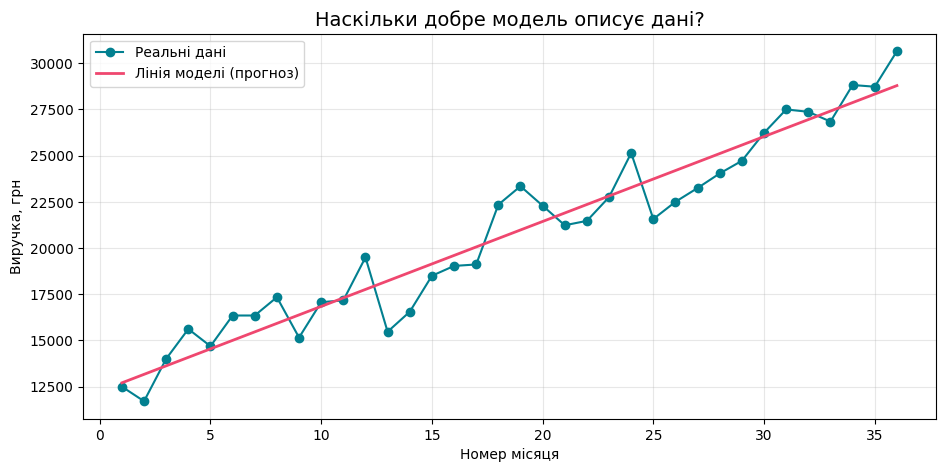

In [19]:
# Прогноз моделі для всіх наявних місяців
df["predicted"] = model.predict(X)

plt.figure(figsize=(11, 5))
plt.plot(df["month_number"], df["revenue"], marker="o", color="#028090", label="Реальні дані")
plt.plot(df["month_number"], df["predicted"], color="#EF476F", linewidth=2, label="Лінія моделі (прогноз)")
plt.title("Наскільки добре модель описує дані?", fontsize=14)
plt.xlabel("Номер місяця")
plt.ylabel("Виручка, грн")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### ❓ Питання 3 (інтерпретація)

1. Наскільки добре червона лінія «ловить» загальний тренд синіх точок?
2. Точки не лежать ідеально на лінії — вони то вище, то нижче. **Чому**, на вашу думку? (згадайте про сезонність)
3. Чи вважаєте ви, що проста пряма лінія — це достатньо добре для директора, чи потрібна складніша модель?

💡 *UA Відповідь*

Червона лінія досить добре відображає загальний тренд даних. Вона показує поступове зростання виручки протягом усього досліджуваного періоду, хоча не проходить точно через кожну точку.

Сині точки розташовані то вище, то нижче лінії, оскільки фактична виручка змінюється під впливом різних факторів. Ймовірно, це пов'язано із сезонними коливаннями, акціями, святами, погодними умовами або іншими подіями, які проста лінійна модель не враховує.

На мою думку, для загальної оцінки тенденції така модель є достатньо корисною для директора кав'ярні, оскільки вона наочно показує основний напрямок розвитку бізнесу. Проте для більш точного прогнозування, особливо якщо сезонність підтвердиться під час детальнішого аналізу, доцільно використовувати складніші моделі.

---

💡 *DE Interpretation*

Die rote Regressionslinie beschreibt den allgemeinen Trend der Daten recht gut. Sie zeigt einen kontinuierlichen Anstieg des Umsatzes über den gesamten Beobachtungszeitraum, verläuft jedoch nicht exakt durch jeden einzelnen Datenpunkt.

Die tatsächlichen Werte liegen teilweise über und teilweise unter der Regressionslinie. Das deutet darauf hin, dass der Umsatz von weiteren Faktoren beeinflusst wird, beispielsweise von saisonalen Schwankungen, Werbeaktionen, Feiertagen, Wetterbedingungen oder anderen Ereignissen, die in diesem einfachen linearen Modell nicht berücksichtigt werden.

Meiner Ansicht nach ist dieses Modell für die Geschäftsleitung ausreichend, um die grundsätzliche Entwicklung des Umsatzes zu erkennen. Für genauere Prognosen – insbesondere wenn sich saisonale Muster bestätigen – wäre jedoch ein komplexeres Prognosemodell sinnvoll.


## Крок 7. 🔮 Прогноз на майбутнє

А тепер — головне, заради чого все робилось. Спрогнозуємо виручку на **наступні 6 місяців** (місяці 37–42, тобто перша половина 2025 року).

Заповніть пропуск: створіть список майбутніх номерів місяців від 37 до 42.

In [20]:
# Майбутні місяці: 37, 38, 39, 40, 41, 42
future_months = pd.DataFrame({"month_number": [37, 38, 39, 40, 41, 42]})   # ⬅️ ВАШ КОД

# Прогнозуємо виручку для них
future_predictions = model.predict(future_months)

# Показуємо результат
for m, pred in zip(future_months["month_number"], future_predictions):
    print(f"Місяць {m}: прогноз ≈ {pred:.0f} грн")

Місяць 37: прогноз ≈ 29242 грн
Місяць 38: прогноз ≈ 29701 грн
Місяць 39: прогноз ≈ 30161 грн
Місяць 40: прогноз ≈ 30620 грн
Місяць 41: прогноз ≈ 31079 грн
Місяць 42: прогноз ≈ 31539 грн


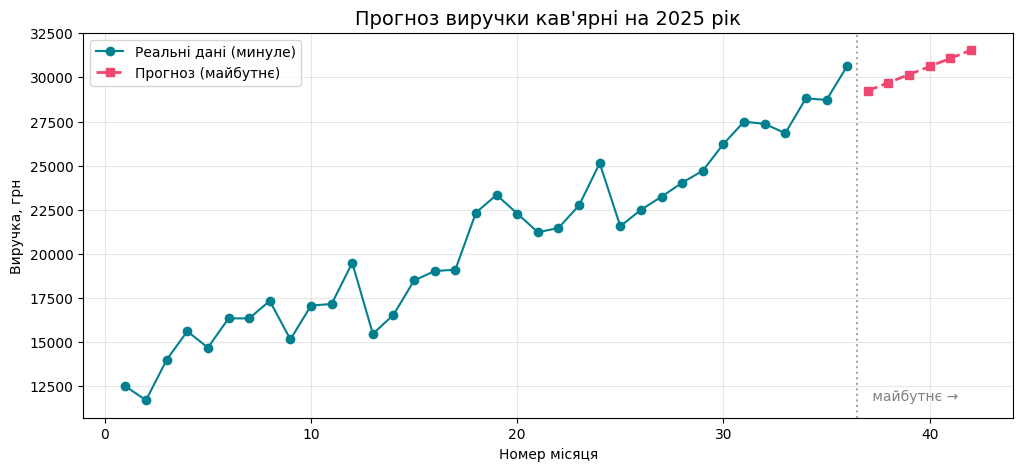

In [21]:
# Побудуємо фінальний графік: минуле + прогноз
plt.figure(figsize=(12, 5))

# Реальні дані
plt.plot(df["month_number"], df["revenue"], marker="o", color="#028090", label="Реальні дані (минуле)")

# Прогноз на майбутнє
plt.plot(future_months["month_number"], future_predictions,
         marker="s", color="#EF476F", linewidth=2, linestyle="--", label="Прогноз (майбутнє)")

plt.axvline(x=36.5, color="gray", linestyle=":", alpha=0.7)
plt.text(37, df["revenue"].min(), " майбутнє →", color="gray")
plt.title("Прогноз виручки кав'ярні на 2025 рік", fontsize=14)
plt.xlabel("Номер місяця")
plt.ylabel("Виручка, грн")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### ❓ Питання 4 (інтерпретація — найважливіше!)

1. Яку виручку модель прогнозує на **місяць 42** (червень 2025)?
2. Директор питає: «**Чи можна повністю довіряти цьому прогнозу?**» Що ви відповісте? Назвіть хоча б **дві причини**, чому реальність може відрізнятись від прогнозу.
3. Наша модель малює **пряму лінію** — вона припускає, що зростання триватиме вічно тим самим темпом. У яких ситуаціях це припущення може бути **небезпечним** для бізнесу?

**Ваша відповідь:**

...


## Крок 8. ⭐ Бонусне завдання (необов'язкове)

Спробуйте спрогнозувати виручку на **один конкретний місяць** — наприклад, місяць 50 (лютий 2026).

Підказка: скопіюйте логіку з Кроку 7, але передайте лише одне число.

In [22]:
# Ваш експеримент тут:
one_month = pd.DataFrame({"month_number": [50]})
prediction = model.predict(one_month)
print(f"Прогноз на місяць 50: {prediction[0]:.0f} грн")

# ❓ Питання-бонус: чим ДАЛІ в майбутнє ми прогнозуємо, тим прогноз...
#    (надійніший чи менш надійний?) Чому? Напишіть відповідь коментарем нижче:
# Відповідь: ...

Прогноз на місяць 50: 35213 грн


## 🎓 Підсумок

Вітаємо! Ви щойно:
- ✅ Завантажили й дослідили реальні дані
- ✅ Навчили модель машинного навчання (лінійну регресію)
- ✅ Зробили прогноз на майбутнє
- ✅ **Найголовніше — навчились інтерпретувати результати й розуміти обмеження моделі**

### Що здати
Збережіть цей ноутбук з **усіма відповідями** на питання 1–4 (і бонус) та надішліть викладачу.

### Головний урок
Модель — це лише інструмент. Її прогноз рівно настільки хороший, наскільки хороші дані й наскільки розумно ви інтерпретуєте результат. **Аналітик, який розуміє обмеження моделі, цінніший за того, хто просто вміє натиснути `.fit()`.**